# Лабораторная работа №1
## Низкоуровневый анализ, предобработка текста и статистическое языковое моделирование

Датасет: IMDB Dataset of 50K Movie Reviews (Kaggle, lakshmi25npathi), колонки `review` (текст
отзыва) и `sentiment` (positive/negative, используется только как класс для стратификации при
разбиении).

### Содержание
0. Настройка окружения
1. Загрузка датасета и разбиение Train/Test
2. Структура обучающей выборки
3. Типы специфического шума
4. Конвейер очистки текста
5. Сравнительная нормализация: стемминг vs лемматизация
6. Поиск опечаток через расстояние Левенштейна
7. N-граммная языковая модель и словарь с `[UNK]`
8. Сглаживание вероятностей и перплексия
9. Генерация текста на основе марковской цепи
10. Заключение


### Шаг 0. Настройка окружения

In [1]:
import os
import re
import html
import math
import time
import random
import sys
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import nltk

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = os.path.join("data", "IMDB Dataset.csv")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 4.5)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

print("Python:", sys.version)


Python: 3.11.0 (v3.11.0:deaf509e8f, Oct 24 2022, 14:43:23) [Clang 13.0.0 (clang-1300.0.29.30)]


In [2]:
NLTK_PACKAGES = ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab",
                  "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng", "words"]
for pkg in NLTK_PACKAGES:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print("warning: could not download", pkg, e)


### Шаг 1. Загрузка датасета и разбиение Train/Test

Разбиение: 80/20, стратификация по `sentiment`, без отдельной Validation-выборки. Дубликаты
текста удаляются до разбиения, иначе одна и та же рецензия может попасть в обе выборки.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print("Размер сырого датасета:", df_raw.shape)
print("\nПропуски:\n", df_raw.isnull().sum())


Размер сырого датасета: (50000, 2)

Пропуски:
 review       0
sentiment    0
dtype: int64


sentiment
positive    25000
negative    25000
Name: count, dtype: int64
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


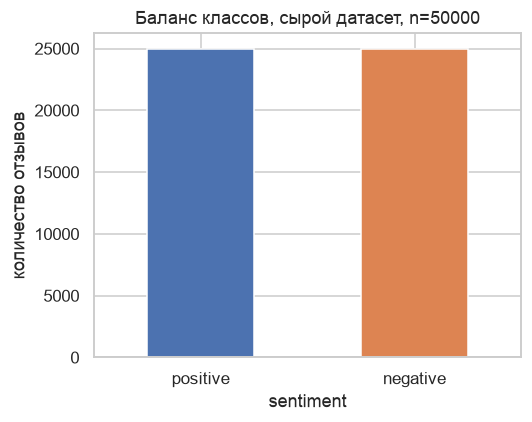

In [4]:
print(df_raw["sentiment"].value_counts())
print(df_raw["sentiment"].value_counts(normalize=True).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
df_raw["sentiment"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Баланс классов, сырой датасет, n=%d" % len(df_raw))
ax.set_xlabel("sentiment"); ax.set_ylabel("количество отзывов")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_class_balance_raw.png"))
plt.show()


In [5]:
n_text_dup_rows = df_raw.duplicated(subset=["review"]).sum()
dup_mask = df_raw.duplicated(subset=["review"], keep=False)
dup_groups = df_raw[dup_mask].groupby("review")["sentiment"].nunique()
print(f"Строк с повторяющимся текстом рецензии: {n_text_dup_rows}")
print(f"Групп дублей: {dup_groups.shape[0]}, с противоречивой меткой внутри группы: {(dup_groups > 1).sum()}")

df = df_raw.drop_duplicates(subset=["review"]).reset_index(drop=True)
print(f"После удаления дублей: {df_raw.shape[0]} -> {df.shape[0]} "
      f"(удалено {df_raw.shape[0] - df.shape[0]}, {(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]:.2%})")


Строк с повторяющимся текстом рецензии: 418
Групп дублей: 406, с противоречивой меткой внутри группы: 0
После удаления дублей: 50000 -> 49582 (удалено 418, 0.84%)


In [6]:
TEXT_COL = "review"
TARGET_COL = "sentiment"

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df[TARGET_COL], random_state=SEED
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {train_df.shape[0]} ({train_df.shape[0]/df.shape[0]:.1%})")
print(f"Test:  {test_df.shape[0]} ({test_df.shape[0]/df.shape[0]:.1%})")
print("\nДоли классов:")
for name, part in [("train", train_df), ("test", test_df)]:
    print(f"  {name}: {dict(part[TARGET_COL].value_counts(normalize=True).round(4))}")


Train: 39665 (80.0%)
Test:  9917 (20.0%)

Доли классов:
  train: {'positive': np.float64(0.5019), 'negative': np.float64(0.4981)}
  test: {'positive': np.float64(0.5019), 'negative': np.float64(0.4981)}


Исходный датасет сбалансирован (25000/25000), пропусков нет. Дубликаты текста удалены до
разбиения. Train/Test разбиты 80/20 со стратификацией по `sentiment`, доли классов в обеих
выборках совпадают с исходными.

### Шаг 2. Структура обучающей выборки

Все статистики этого шага, число документов, длина в словах и символах, распределение длин,
топ-30 стоп-слов, считаются на Train.

In [7]:
n_train_docs = len(train_df)
words_per_doc = train_df[TEXT_COL].str.split().apply(len)
chars_per_doc = train_df[TEXT_COL].str.len()

print(f"Документов в Train: {n_train_docs}")
print(f"Средняя длина в словах: {words_per_doc.mean():.1f} (медиана {words_per_doc.median():.0f}, "
      f"min {words_per_doc.min()}, max {words_per_doc.max()})")
print(f"Средняя длина в символах: {chars_per_doc.mean():.1f} (медиана {chars_per_doc.median():.0f}, "
      f"min {chars_per_doc.min()}, max {chars_per_doc.max()})")
print(f"95-й перцентиль длины (слов): {words_per_doc.quantile(0.95):.0f}")
print(f"99-й перцентиль длины (слов): {words_per_doc.quantile(0.99):.0f}")


Документов в Train: 39665
Средняя длина в словах: 231.5 (медиана 173, min 4, max 2470)
Средняя длина в символах: 1311.5 (медиана 973, min 32, max 13704)
95-й перцентиль длины (слов): 590
99-й перцентиль длины (слов): 910


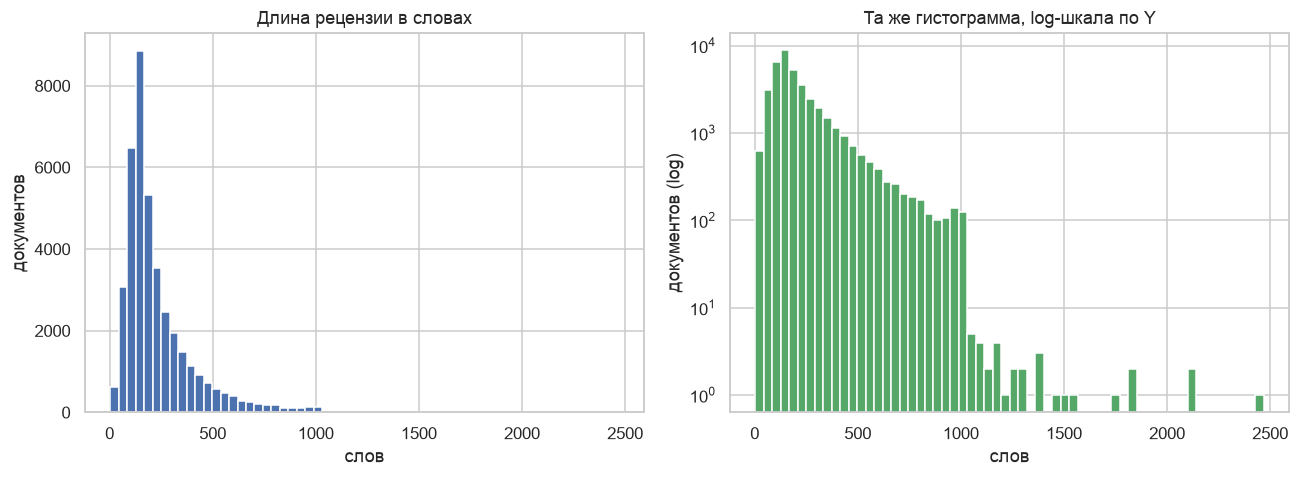

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(words_per_doc, bins=60, color="#4C72B0")
axes[0].set_title("Длина рецензии в словах")
axes[0].set_xlabel("слов"); axes[0].set_ylabel("документов")

axes[1].hist(words_per_doc, bins=60, color="#55A868")
axes[1].set_yscale("log")
axes[1].set_title("Та же гистограмма, log-шкала по Y")
axes[1].set_xlabel("слов"); axes[1].set_ylabel("документов (log)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_length_distribution_words.png"))
plt.show()


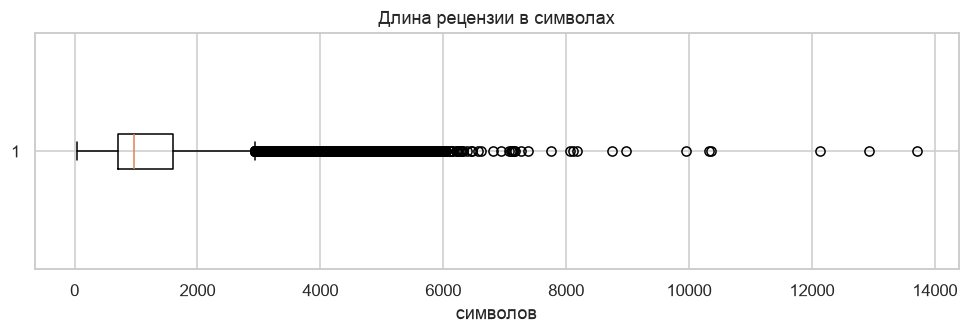

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.boxplot(chars_per_doc, orientation="horizontal", showfliers=True)
ax.set_title("Длина рецензии в символах")
ax.set_xlabel("символов")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_length_boxplot_chars.png"))
plt.show()


In [10]:
from nltk.corpus import stopwords as nltk_stopwords
stop_set = set(nltk_stopwords.words("english"))

WORD_ONLY_RE = re.compile(r"[a-z']+")
def rough_words(text):
    return WORD_ONLY_RE.findall(text.lower())

train_words_flat = train_df[TEXT_COL].map(rough_words)
stopword_counts = Counter()
for doc in train_words_flat:
    stopword_counts.update(w for w in doc if w in stop_set)

top30 = stopword_counts.most_common(30)
print("Топ-30 стоп-слов в Train:")
for w, c in top30:
    print(f"  {w:12s} {c}")


Топ-30 стоп-слов в Train:
  the          529754
  and          258045
  a            256819
  of           230097
  to           212544
  is           167549
  in           148540
  it           124849
  i            122945
  this         119751
  that         108853
  was          76008
  as           72863
  for          69573
  with         69163
  but          66308
  on           53914
  not          48131
  you          47824
  are          46200
  his          45847
  have         43853
  be           42392
  he           41834
  all          37270
  at           37145
  by           35292
  an           34058
  they         33291
  so           32405


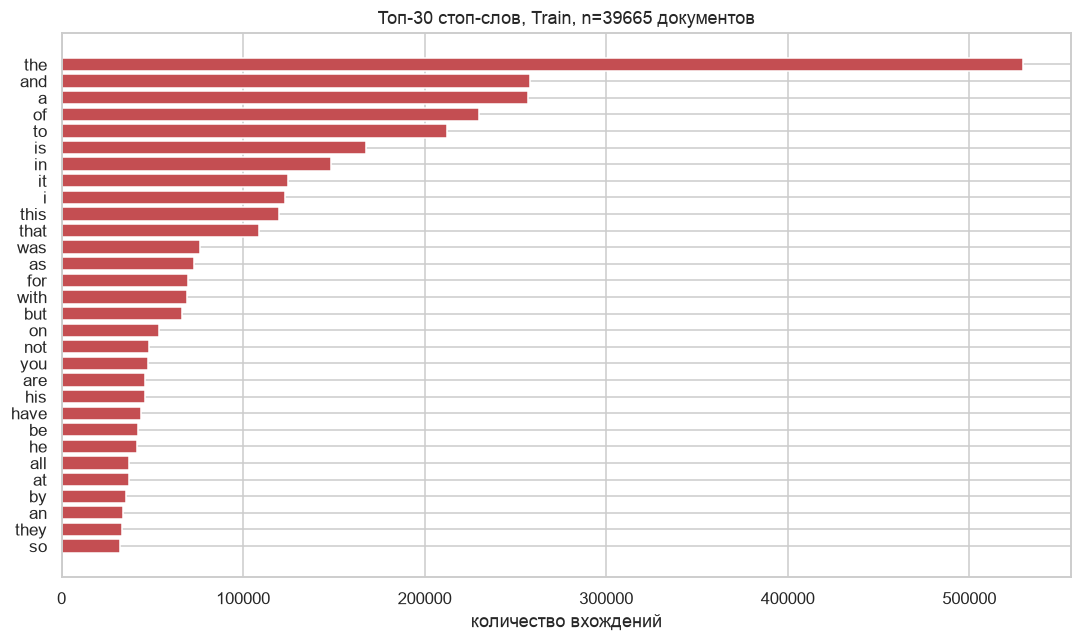

In [11]:
labels, counts = zip(*top30)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels[::-1], counts[::-1], color="#C44E52")
ax.set_title("Топ-30 стоп-слов, Train, n=%d документов" % n_train_docs)
ax.set_xlabel("количество вхождений")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_top30_stopwords.png"))
plt.show()


Распределение длины смещено вправо: медиана заметно ниже среднего, есть длинный хвост
редких очень длинных рецензий, поэтому гистограмма продублирована в log-шкале. Топ-30 стоп-слов
заняты служебными частями речи (артикли, предлоги, местоимения), что соответствует ожиданиям для
английского текста.

### Шаг 3. Типы специфического шума

Анализ на Train. Проверяется более широкий набор типов, чем минимально требуется, чтобы показать
и то, каких типов шума в датасете почти нет.

In [12]:
NOISE_PATTERNS = {
    "HTML-теги (напр. <br />)":       re.compile(r"</?[a-zA-Z][^<>]{0,20}>"),
    "HTML-сущности (&amp; и т.п.)":   re.compile(r"&[a-zA-Z#0-9]+;"),
    "URL-адреса":                     re.compile(r"https?://\S+|www\.\S+"),
    "E-mail адреса":                  re.compile(r"\S+@\S+\.\S+"),
    "Числа":                          re.compile(r"\b\d[\d,.:/-]*[a-zA-Z]*\b"),
    "ALL-CAPS слова (>=2 букв)":      re.compile(r"\b[A-Z]{2,}\b"),
    "Повторяющаяся пунктуация":       re.compile(r"[!?.,;:]{2,}"),
    "Не-ASCII символы":               re.compile(r"[^\x00-\x7F]"),
    "Двойные/множественные пробелы":  re.compile(r"\s{2,}"),
    "Эмодзи (юникод-блоки)":          re.compile(r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF]"),
    "Сокращения/отрицания (don't...)": re.compile(r"\b\w+'\w+\b"),
}

n_train = len(train_df)
rows = []
for name, pat in NOISE_PATTERNS.items():
    docs_with = train_df[TEXT_COL].map(lambda t: bool(pat.search(t))).sum()
    total_hits = train_df[TEXT_COL].map(lambda t: len(pat.findall(t))).sum()
    rows.append({"Тип шума": name, "Документов с шумом": docs_with,
                 "Доля документов": docs_with / n_train, "Всего вхождений": total_hits})

noise_table = pd.DataFrame(rows).sort_values("Документов с шумом", ascending=False).reset_index(drop=True)
noise_table_display = noise_table.copy()
noise_table_display["Доля документов"] = noise_table_display["Доля документов"].map(lambda x: f"{x:.2%}")
noise_table_display


,Тип шума,Документов с шумом,Доля документов,Всего вхождений
0,Сокращения/отрицания (don't...),34757,87.63%,181048
1,HTML-теги (напр. <br />),23180,58.44%,160646
2,Числа,21900,55.21%,54669
3,ALL-CAPS слова (>=2 букв),19258,48.55%,66119
4,Повторяющаяся пунктуация,12212,30.79%,28320
5,Не-ASCII символы,3702,9.33%,9137
6,Двойные/множественные пробелы,335,0.84%,716
7,URL-адреса,157,0.40%,167
8,E-mail адреса,39,0.10%,44
9,HTML-сущности (&amp; и т.п.),9,0.02%,16


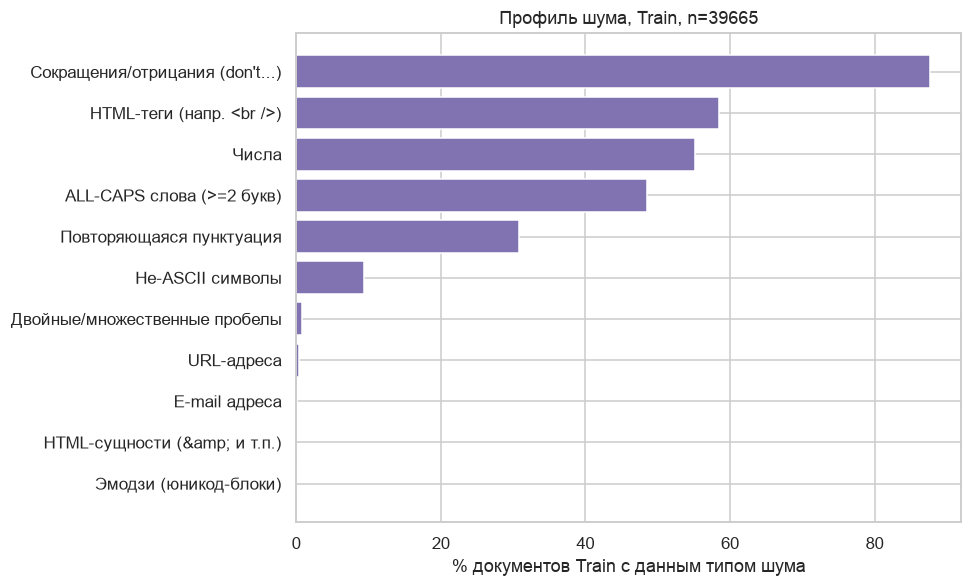

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = noise_table.sort_values("Документов с шумом")
ax.barh(plot_df["Тип шума"], plot_df["Документов с шумом"] / n_train * 100, color="#8172B2")
ax.set_xlabel("% документов Train с данным типом шума")
ax.set_title(f"Профиль шума, Train, n={n_train}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_noise_profile.png"))
plt.show()


In [14]:
def show_context(pattern, series, n=2, window=60):
    found = 0
    for t in series:
        m = pattern.search(t)
        if m:
            lo, hi = max(0, m.start() - window), min(len(t), m.end() + window)
            print("  ...", t[lo:hi].replace(chr(10), " "), "...")
            found += 1
            if found >= n:
                break

for name in ["HTML-теги (напр. <br />)", "Числа", "ALL-CAPS слова (>=2 букв)",
             "Повторяющаяся пунктуация", "Не-ASCII символы", "URL-адреса"]:
    print(f"### {name}")
    show_context(NOISE_PATTERNS[name], train_df[TEXT_COL], n=2)
    print()


### HTML-теги (напр. <br />)
  ...  western pre-conceptions of Africans and, especially, Arabs.<br /><br />Dr Anansa Linderby, the beautiful African-American wif ...
  ... e success stories and made superstars out of these fighters.<br /><br />Fast forward almost 40 years later and this movie stil ...

### Числа
  ... eing told that they will die if they refuse blood and after 26 years in the field I have never actually seen it happen, le ...
  ...  advantage, but don't go nuts. And why the hell did it take 44 minutes to solve everything anyway? I'd say that's a very l ...

### ALL-CAPS слова (>=2 букв)
  ... cked the horror shelves over the last ten or so years since SCREAM. While I've never liked any of Cuoco's characters, I never  ...
  ... n many martial arts films, a few even better, but this is a MUST-SEE for fans of the genre. You can't go wrong here. The mov ...

### Повторяющаяся пунктуация
  ... rs to everyone, her poisonous attitude creating much tension..she's the type of p

В корпусе Train преобладают 4 типа шума: сокращения/отрицания (87.6% документов, это не шум
для удаления, конвейер очистки обязан их сохранить), HTML-теги (58.4%, в основном `<br />`),
числа (55.2%), ALL-CAPS слова (48.6%). Повторяющаяся пунктуация встречается в 30.8% документов,
не-ASCII символы в 9.3%. URL, e-mail и HTML-сущности редки (0.4%, 0.1%, 0.02%). Эмодзи в Train не
найдены (0 документов).

### Шаг 4. Конвейер очистки текста

Правила применяются каскадом, каждый тип шума обрабатывается отдельным правилом:

1. `html.unescape` раскрывает HTML-сущности;
2. HTML-теги вырезаются регулярным выражением `</?[a-zA-Z][^<>]{0,20}>`. Жадный шаблон `<[^>]+>`
   даёт ложные срабатывания на символах `<`/`>`, используемых как смайлик (`>.<`) или знак
   «меньше» (например, `< 10 minutes`), и стирает текст между ними и следующим случайным `>`. Требование
   буквы сразу после `<` и ограничение длины содержимого убирают эту ошибку;
3. URL-адреса заменяются на `[URL]`;
4. e-mail адреса на `[EMAIL]`;
5. числа (включая формы `1990s`, `10/10`) на `[NUM]`;
6. не-ASCII символы вырезаются;
7. повторяющаяся пунктуация схлопывается до одного символа;
8. повторяющиеся буквы (`sooooo`) схлопываются до двух;
9. множественные пробелы схлопываются до одного;
10. текст приводится к нижнему регистру;
11. документ обрамляется токенами `<s>` и `</s>`.

Сокращения и отрицания (`don't`, `isn't`) не разворачиваются.

In [15]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
HTML_TAG_RE = re.compile(r"</?[a-zA-Z][^<>]{0,20}>")
NUM_RE = re.compile(r"\b\d[\d,.:/-]*[a-zA-Z]*\b")
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]+")
REPEAT_PUNCT_RE = re.compile(r"([!?.,;:])\1{1,}")
REPEAT_LETTER_RE = re.compile(r"([a-zA-Z])\1{2,}")
MULTI_WS_RE = re.compile(r"\s{2,}")


def clean_document(text: str) -> str:
    t = html.unescape(text)
    t = HTML_TAG_RE.sub(" ", t)
    t = URL_RE.sub(" [URL] ", t)
    t = EMAIL_RE.sub(" [EMAIL] ", t)
    t = NUM_RE.sub(" [NUM] ", t)
    t = NON_ASCII_RE.sub(" ", t)
    t = REPEAT_PUNCT_RE.sub(r"\1", t)
    t = REPEAT_LETTER_RE.sub(r"\1\1", t)
    t = MULTI_WS_RE.sub(" ", t).strip()
    t = t.lower()
    return f"<s> {t} </s>"


TOKEN_RE = re.compile(r"<s>|</s>|\[[a-z]+\]|[a-z]+'[a-z]+|[a-z]+|[.,!?;:]")

def tokenize(text: str):
    return TOKEN_RE.findall(text)


In [16]:
examples = df[TEXT_COL].iloc[[0, 5]].tolist()
for ex in examples:
    print("RAW:  ", ex[:220].replace(chr(10), " "))
    cleaned = clean_document(ex)
    print("CLEAN:", cleaned[:220])
    print("TOK:  ", tokenize(cleaned)[:25])
    print("-" * 100)


RAW:   One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutal
CLEAN: <s> one of the other reviewers has mentioned that after watching just [num] oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was its brutality
TOK:   ['<s>', 'one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '[num]', 'oz', 'episode', "you'll", 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this']
----------------------------------------------------------------------------------------------------
RAW:   Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last
C

In [17]:
synthetic = "Great movie.<br />Next scene was AMAZING!!! Price: $19.99, visit http://x.com now, from the 1990s."
print("RAW:  ", synthetic)
c = clean_document(synthetic)
print("CLEAN:", c)
print("TOK:  ", tokenize(c))


RAW:   Great movie.<br />Next scene was AMAZING!!! Price: $19.99, visit http://x.com now, from the 1990s.
CLEAN: <s> great movie. next scene was amazing! price: $ [num] , visit [url] now, from the [num] . </s>
TOK:   ['<s>', 'great', 'movie', '.', 'next', 'scene', 'was', 'amazing', '!', 'price', ':', '[num]', ',', 'visit', '[url]', 'now', ',', 'from', 'the', '[num]', '.', '</s>']


In [18]:
t0 = time.time()
train_clean = train_df[TEXT_COL].map(clean_document)
test_clean = test_df[TEXT_COL].map(clean_document)
print(f"Очистка train/test заняла {time.time()-t0:.1f}с")

t0 = time.time()
train_tokens = train_clean.map(tokenize)
test_tokens = test_clean.map(tokenize)
print(f"Токенизация train/test заняла {time.time()-t0:.1f}с")
print("Пример токенов:", train_tokens.iloc[0][:20])


Очистка train/test заняла 4.3с


Токенизация train/test заняла 1.4с
Пример токенов: ['<s>', 'i', 'am', 'one', 'of', "jehovah's", 'witnesses', 'and', 'i', 'also', 'work', 'in', 'an', 'acute', 'care', 'medical', 'facility', '.', 'over', 'the']


In [19]:
real_tag_re = re.compile(r"</?[a-zA-Z][^<>]{0,20}>")
leftover_tags = train_clean.map(lambda t: bool(real_tag_re.search(t.replace("<s>", "").replace("</s>", "")))).sum()
leftover_urls = train_clean.str.contains(URL_RE).sum()
leftover_emails = train_clean.str.contains(EMAIL_RE).sum()
raw_digit_re = re.compile(r"\d")
leftover_digits = train_clean.map(lambda t: bool(raw_digit_re.search(t))).sum()

print(f"Документов с настоящими HTML-тегами после очистки: {leftover_tags}")
print(f"Документов с URL после очистки: {leftover_urls}")
print(f"Документов с e-mail после очистки: {leftover_emails}")
print(f"Документов с цифрами после очистки: {leftover_digits} "
      f"(цифры внутри идентификаторов вида mst3k, не отделённых границей слова от букв)")


Документов с настоящими HTML-тегами после очистки: 0
Документов с URL после очистки: 0
Документов с e-mail после очистки: 0
Документов с цифрами после очистки: 863 (цифры внутри идентификаторов вида mst3k, не отделённых границей слова от букв)


Конвейер устраняет HTML-теги, URL и e-mail полностью (0 документов с остатками), заменяет
числа/URL/e-mail на токены вместо удаления, сохраняет сокращения и отрицания. Цифры внутри
буквенно-цифровых идентификаторов (`mst3k`) не считаются числами и не заменяются, это ожидаемое
поведение шаблона `\b\d...\b`.

### Шаг 5. Сравнительная нормализация: стемминг vs лемматизация

Сравнение на словаре уникальных буквенных токенов Train (`.isalpha()`, без `<s>`/`</s>`; это
исключает также сокращения вида `don't`, где есть апостроф).

Стемминг не зависит от контекста, применяется сразу ко всему словарю типов. Лемматизация
POS-aware зависит от части речи слова в предложении, поэтому применяется к токенам всех
документов Train в контексте (`nltk.pos_tag` по предложению целиком, затем `WordNetLemmatizer`).
POS-тэггинг, самая медленная операция ноутбука, время показано отдельно от времени самой
лемматизации.

In [20]:
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

train_tokens_list = train_tokens.tolist()
SPECIAL_TOKENS = {"<s>", "</s>"}

def is_alpha_word(tok):
    return tok.isalpha() and tok not in SPECIAL_TOKENS

raw_vocab = sorted({t for doc in train_tokens_list for t in doc if is_alpha_word(t)})
print(f"Словарь буквенных словоформ Train (без пунктуации, спецтокенов, сокращений с апострофом): {len(raw_vocab)}")


Словарь буквенных словоформ Train (без пунктуации, спецтокенов, сокращений с апострофом): 89282


In [21]:
stemmer = SnowballStemmer("english")
t0 = time.time()
stem_map = {w: stemmer.stem(w) for w in raw_vocab}
stem_time = time.time() - t0
stemmed_vocab = set(stem_map.values())
print(f"Время стемминга всего словаря ({len(raw_vocab)} слов): {stem_time:.2f}с")
print(f"Размер словаря после стемминга: {len(stemmed_vocab)} "
      f"(сокращение {(1 - len(stemmed_vocab)/len(raw_vocab)):.1%})")

for w in ["running", "runner", "better", "movies", "movie", "happiness", "studies"]:
    print(f"  {w:12s} -> {stem_map.get(w, '?')}")


Время стемминга всего словаря (89282 слов): 0.34с
Размер словаря после стемминга: 60652 (сокращение 32.1%)
  running      -> run
  runner       -> runner
  better       -> better
  movies       -> movi
  movie        -> movi
  happiness    -> happi
  studies      -> studi


In [22]:
def get_wordnet_pos(tag):
    if tag.startswith("J"): return wordnet.ADJ
    if tag.startswith("V"): return wordnet.VERB
    if tag.startswith("N"): return wordnet.NOUN
    if tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN

lemmatizer = WordNetLemmatizer()

t0 = time.time()
pos_tagged_docs = [nltk.pos_tag(doc) for doc in train_tokens_list]
pos_time = time.time() - t0
print(f"Время POS-тэггинга Train ({len(train_tokens_list)} документов): {pos_time:.1f}с")


Время POS-тэггинга Train (39665 документов): 98.7с


In [23]:
t0 = time.time()
lemma_vocab = set()
lemma_examples = {}
for doc in pos_tagged_docs:
    for w, tag in doc:
        if is_alpha_word(w):
            lemma = lemmatizer.lemmatize(w, get_wordnet_pos(tag))
            lemma_vocab.add(lemma)
            lemma_examples.setdefault(w, lemma)
lemma_time = time.time() - t0
print(f"Время лемматизации (без POS-тэггинга): {lemma_time:.1f}с")
print(f"Размер словаря после лемматизации: {len(lemma_vocab)} "
      f"(сокращение {(1 - len(lemma_vocab)/len(raw_vocab)):.1%})")

speed_ratio = (pos_time + lemma_time) / stem_time
print(f"Полное время лемматизации (POS + лемматизация): {pos_time + lemma_time:.1f}с, "
      f"это в {speed_ratio:.0f} раз медленнее стемминга")

for w in ["running", "runner", "better", "movies", "studies", "was", "were", "children"]:
    print(f"  {w:12s} -> {lemma_examples.get(w, '?')}")


Время лемматизации (без POS-тэггинга): 15.6с
Размер словаря после лемматизации: 77693 (сокращение 13.0%)
Полное время лемматизации (POS + лемматизация): 114.3с, это в 333 раз медленнее стемминга
  running      -> run
  runner       -> runner
  better       -> good
  movies       -> movie
  studies      -> study
  was          -> be
  were         -> be
  children     -> child


In [24]:
comparison = pd.DataFrame({
    "Метод": ["Без нормализации", "Стемминг (Snowball)", "Лемматизация (WordNet, POS-aware)"],
    "Размер словаря": [len(raw_vocab), len(stemmed_vocab), len(lemma_vocab)],
    "Сокращение, %": [0.0,
                       (1 - len(stemmed_vocab)/len(raw_vocab)) * 100,
                       (1 - len(lemma_vocab)/len(raw_vocab)) * 100],
    "Время, с": [0.0, stem_time, pos_time + lemma_time],
})
comparison


,Метод,Размер словаря,"Сокращение, %","Время, с"
0,Без нормализации,89282,0.000000,0.000000
1,Стемминг (Snowball),60652,32.066934,0.343550
2,"Лемматизация (WordNet, POS-aware)",77693,12.980220,114.328172


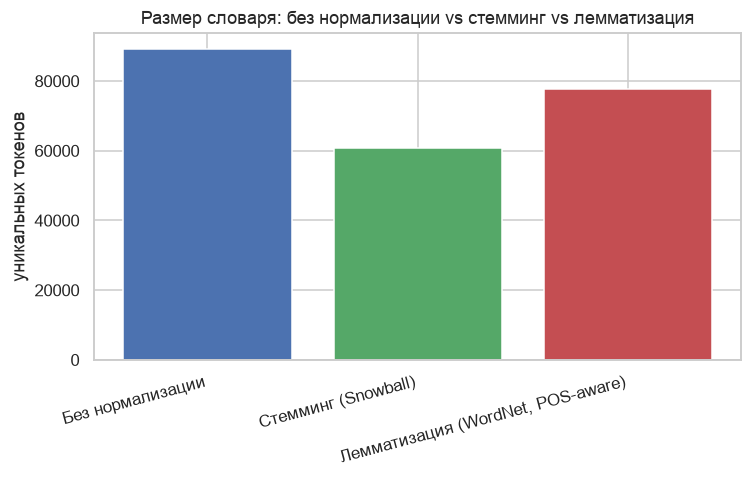

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(comparison["Метод"], comparison["Размер словаря"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("уникальных токенов")
ax.set_title("Размер словаря: без нормализации vs стемминг vs лемматизация")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_vocab_normalization.png"))
plt.show()


Оба метода сокращают словарь: стемминг сильнее, но иногда даёт не-слова (`happiness` ->
`happi`). Лемматизация сохраняет существующие словоформы (`better` -> `good` при верном POS,
`children` -> `child`), но требует POS-контекста, точный коэффициент замедления относительно
стемминга посчитан в коде выше (`speed_ratio`). Для N-граммной модели в этой работе используется
токенизированный текст в нижнем регистре без стемминга и лемматизации: стемминг искажает
поверхностную форму слов, важную для читаемости генерации в Шаге 9, а выигрыш от лемматизации для
этой задачи не оправдывает её стоимость.

### Шаг 6. Поиск опечаток через расстояние Левенштейна

Расстояние Левенштейна реализовано вручную, без сторонних библиотек, с оптимизацией по памяти:
вместо полной матрицы `O(n*m)` хранятся только две бегущие строки `O(min(n,m))`. Проверка на
классических примерах.

Сравнение всех пар словаря (`O(V^2)`) неосуществимо: при V примерно 85 тысяч слов это несколько
миллиардов пар (точное число ниже, в коде). Вместо этого строится индекс удалений по принципу
SymSpell: для каждого слова
генерируются варианты с одним удалённым символом; если у двух разных слов совпадает хотя бы один
такой вариант (или само слово), их расстояние Левенштейна не превышает 2. Поэтому точная проверка
Левенштейна ниже уже не отсеивает кандидатов: расстояние 1 или 2 гарантировано заранее, проверка
только определяет, какое из двух значений верно для конкретной пары.

In [26]:
def levenshtein(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        curr = [i] + [0] * len(b)
        for j, cb in enumerate(b, start=1):
            cost = 0 if ca == cb else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return prev[-1]


_CLASSIC_CASES = [
    ("kitten", "sitting", 3), ("flaw", "lawn", 2), ("intention", "execution", 5),
    ("", "abc", 3), ("abc", "abc", 0), ("gray", "grey", 1), ("movie", "movei", 2),
]
for a, b, expected in _CLASSIC_CASES:
    got = levenshtein(a, b)
    status = "OK" if got == expected else "FAIL"
    print(f"{status}: lev({a!r},{b!r})={got} (ожидание {expected})")


OK: lev('kitten','sitting')=3 (ожидание 3)
OK: lev('flaw','lawn')=2 (ожидание 2)
OK: lev('intention','execution')=5 (ожидание 5)
OK: lev('','abc')=3 (ожидание 3)
OK: lev('abc','abc')=0 (ожидание 0)
OK: lev('gray','grey')=1 (ожидание 1)
OK: lev('movie','movei')=2 (ожидание 2)


In [27]:
def deletion_variants(word, max_depth=1):
    variants = {word}
    frontier = {word}
    for _ in range(max_depth):
        nxt = set()
        for w in frontier:
            for i in range(len(w)):
                nxt.add(w[:i] + w[i + 1:])
        variants |= nxt
        frontier = nxt
    return variants


def build_candidate_pairs(vocab, max_depth=1):
    index = defaultdict(set)
    for w in vocab:
        for v in deletion_variants(w, max_depth):
            index[v].add(w)
    pairs = set()
    for variant, words in index.items():
        if len(words) > 1:
            words = sorted(words)
            for i in range(len(words)):
                for j in range(i + 1, len(words)):
                    pairs.add((words[i], words[j]))
    return pairs


unigram_freq_train = Counter(t for doc in train_tokens_list for t in doc)
typo_vocab = [w for w in unigram_freq_train if is_alpha_word(w) and 4 <= len(w) <= 15]
print(f"Слов-кандидатов (длина 4-15): {len(typo_vocab)}")

t0 = time.time()
candidate_pairs = build_candidate_pairs(typo_vocab, max_depth=1)
print(f"Индекс удалений: {time.time()-t0:.2f}с, кандидатов: {len(candidate_pairs)} "
      f"(вместо {len(typo_vocab)**2//2:,} при полном переборе)")


Слов-кандидатов (длина 4-15): 85978


Индекс удалений: 1.51с, кандидатов: 206139 (вместо 3,696,108,242 при полном переборе)


In [28]:
t0 = time.time()
verified_pairs = []
for a, b in candidate_pairs:
    d = levenshtein(a, b)
    verified_pairs.append((a, b, d, unigram_freq_train[a], unigram_freq_train[b]))
n_d1 = sum(1 for r in verified_pairs if r[2] == 1)
n_d2 = sum(1 for r in verified_pairs if r[2] == 2)
n_other = sum(1 for r in verified_pairs if r[2] not in (1, 2))
print(f"Проверено Левенштейном за {time.time()-t0:.2f}с: distance=1 -> {n_d1}, distance=2 -> {n_d2}, "
      f"другое -> {n_other} (ожидание: 0, все кандидаты из индекса удалений имеют distance<=2)")


Проверено Левенштейном за 0.96с: distance=1 -> 125945, distance=2 -> 80194, другое -> 0 (ожидание: 0, все кандидаты из индекса удалений имеют distance<=2)


In [29]:
from nltk.corpus import words as nltk_words
english_dict = set(w.lower() for w in nltk_words.words())
print(f"Референсный словарь (nltk.corpus.words): {len(english_dict)} слов")

typo_candidates = []
for a, b, d, fa, fb in verified_pairs:
    rare_word, rare_freq = (a, fa) if fa < fb else (b, fb)
    common_word, common_freq = (b, fb) if fa < fb else (a, fa)
    if rare_word == common_word:
        continue
    if rare_freq < 2 or rare_word in english_dict:
        continue
    ratio = common_freq / rare_freq
    typo_candidates.append((ratio, rare_word, rare_freq, common_word, common_freq, d))

# не более одной пары на частое слово, иначе таблицу заполняют варианты одного и того же слова
typo_candidates.sort(key=lambda x: (-x[0], x[1], x[3]))
seen_common = set()
typo_top = []
for row in typo_candidates:
    if row[3] in seen_common:
        continue
    seen_common.add(row[3])
    typo_top.append(row)
    if len(typo_top) == 10:
        break

typo_table = pd.DataFrame(
    [(r[1], r[2], r[3], r[4], r[5], r[0]) for r in typo_top],
    columns=["Редкое слово", "Частота редкого", "Похожее частое слово", "Частота частого",
             "Ed. расстояние", "Отношение частот"]
)
typo_table


Референсный словарь (nltk.corpus.words): 234377 слов


,Редкое слово,Частота редкого,Похожее частое слово,Частота частого,Ed. расстояние,Отношение частот
0,tais,2,this,119773,1,59886.50
1,hawt,2,that,108877,2,54438.50
2,moive,2,movie,69478,2,34739.00
3,flim,2,film,61720,2,30860.00
4,harve,2,have,43861,1,21930.50
5,witt,4,with,69165,1,17291.25
6,thet,2,they,33303,1,16651.50
7,frome,2,from,32301,1,16150.50
8,alik,2,like,31936,2,15968.00
9,juts,2,just,27960,2,13980.00


In [30]:
# морфологическая пара: оба слова сводятся к одному стеммеру Snowball (Шаг 5), в отличие
# от совпадения "оба слова есть в словаре", которое также ловит случайные пары разных слов
# (that/what, well/will) и не годится для иллюстрации словоформ
morph_candidates = []
for a, b, d, fa, fb in verified_pairs:
    if d == 1 and a in english_dict and b in english_dict and stemmer.stem(a) == stemmer.stem(b):
        morph_candidates.append((a, b, min(fa, fb), fa, fb))

morph_candidates.sort(key=lambda x: (-x[2], x[0]))
morph_table = pd.DataFrame(
    [(a, fa, b, fb) for a, b, _, fa, fb in morph_candidates[:10]],
    columns=["Слово 1", "Частота 1", "Слово 2", "Частота 2"]
)
morph_table


,Слово 1,Частота 1,Слово 2,Частота 2
0,time,19939,times,5030
1,come,4988,comes,3778
2,become,2324,becomes,2108
3,work,6746,works,1961
4,turn,2133,turns,1921
5,need,2845,needs,1243
6,lead,2145,leads,1164
7,leave,1711,leaves,1074
8,possible,1505,possibly,1042
9,effect,1039,effects,3664


Первая таблица: кандидаты в опечатки, редкое слово (частота от 2, вне референсного словаря)
рядом с частым словом, не более одной пары на частое слово. Вторая таблица: пары слов из индекса
удалений с одинаковым стеммом, словоформы одного слова (множественное число, окончания), а не
опечатки. Фильтр "оба слова есть в словаре" без проверки стемма недостаточен: он же находит пары
случайно близких по написанию разных слов (`well`/`will`, `that`/`what`), которые не являются
формами одного слова.

### Шаг 7. N-граммная языковая модель и словарь с `[UNK]`

Словарь модели строится на всех типах токенов Train (слова, пунктуация, `[NUM]`, `[URL]`,
`[EMAIL]`, `<s>`, `</s>`), это отдельный, более широкий счётчик, чем буквенный словарь Шага 5
(без пунктуации, спецтокенов и сокращений с апострофом, точное число в выводе Шага 5). Слова с частотой ниже порога
заменяются на `[UNK]` уже в train, иначе модель не сможет оценить его вероятность: `[UNK]` не
встретится в обучении ни разу. `min_count=2` дополнительно оправдан Шагом 6: заметная часть
единично встретившихся слов (hapax legomena), опечатки.

In [31]:
unk_threshold = 2
vocab_words = {w for w, c in unigram_freq_train.items() if c >= unk_threshold}
vocab_words.add("[UNK]")
vocab_list = sorted(vocab_words)
vocab_size = len(vocab_list)

n_hapax = sum(1 for w, c in unigram_freq_train.items() if c == 1)
print(f"Словарь всех типов токенов Train (слова, пунктуация, спецтокены): {len(unigram_freq_train)}")
print(f"  hapax legomena (частота=1): {n_hapax} ({n_hapax/len(unigram_freq_train):.1%})")
print(f"Итоговый словарь модели (частота >= {unk_threshold}, плюс [UNK]): {vocab_size}")

def map_unk(tokens):
    return [t if t in vocab_words else "[UNK]" for t in tokens]

train_unk = [map_unk(d) for d in train_tokens_list]
test_tokens_list = test_tokens.tolist()
test_unk = [map_unk(d) for d in test_tokens_list]

n_unk_in_train = sum(1 for d in train_unk for t in d if t == "[UNK]")
n_train_tokens = sum(len(d) for d in train_unk)
print(f"Доля [UNK] в Train после замены: {n_unk_in_train/n_train_tokens:.2%}")


Словарь всех типов токенов Train (слова, пунктуация, спецтокены): 99239
  hapax legomena (частота=1): 38365 (38.7%)
Итоговый словарь модели (частота >= 2, плюс [UNK]): 60875


Доля [UNK] в Train после замены: 0.37%


In [32]:
n_test_tokens_raw = sum(len(d) for d in test_tokens_list)
n_oov_test = sum(1 for d in test_tokens_list for t in d if t not in vocab_words)
print(f"OOV rate на Test (доля токенов вне словаря модели): {n_oov_test/n_test_tokens_raw:.2%}")


OOV rate на Test (доля токенов вне словаря модели): 0.69%


In [33]:
def pad_sequence(tokens, n):
    if n <= 2:
        return tokens
    return ["<s>"] * (n - 2) + tokens


def build_ngram_counts(token_lists, n):
    ngram_counts = Counter()
    context_counts = Counter()
    for tokens in token_lists:
        seq = pad_sequence(tokens, n)
        for i in range(n - 1, len(seq)):
            context = tuple(seq[i - n + 1:i])
            ngram = context + (seq[i],)
            ngram_counts[ngram] += 1
            context_counts[context] += 1
    return ngram_counts, context_counts


t0 = time.time()
ngram_counts = {}
context_counts = {}
for n in (1, 2, 3):
    ngc, ctxc = build_ngram_counts(train_unk, n)
    ngram_counts[n] = ngc
    context_counts[n] = ctxc
    print(f"N={n}: уникальных n-грамм={len(ngc):,}  уникальных контекстов={len(ctxc):,}  "
          f"(время сборки {time.time()-t0:.1f}с)")


N=1: уникальных n-грамм=60,875  уникальных контекстов=1  (время сборки 2.4с)


N=2: уникальных n-грамм=1,705,117  уникальных контекстов=60,874  (время сборки 7.2с)


N=3: уникальных n-грамм=5,257,567  уникальных контекстов=1,703,846  (время сборки 15.0с)


In [34]:
sparsity_rows = []
for n in (1, 2, 3):
    ngc = ngram_counts[n]
    total = sum(ngc.values())
    hapax = sum(1 for c in ngc.values() if c == 1)
    sparsity_rows.append({
        "N": n, "Уникальных n-грамм": len(ngc), "Всего вхождений n-грамм": total,
        "Hapax n-грамм (freq=1)": hapax, "Доля hapax": hapax / len(ngc),
    })
sparsity_df = pd.DataFrame(sparsity_rows)
sparsity_df


,N,Уникальных n-грамм,Всего вхождений n-грамм,Hapax n-грамм (freq=1),Доля hapax
0,1,60875,10233506,0,0.000000
1,2,1705117,10193841,1146318,0.672281
2,3,5257567,10193841,4357549,0.828815


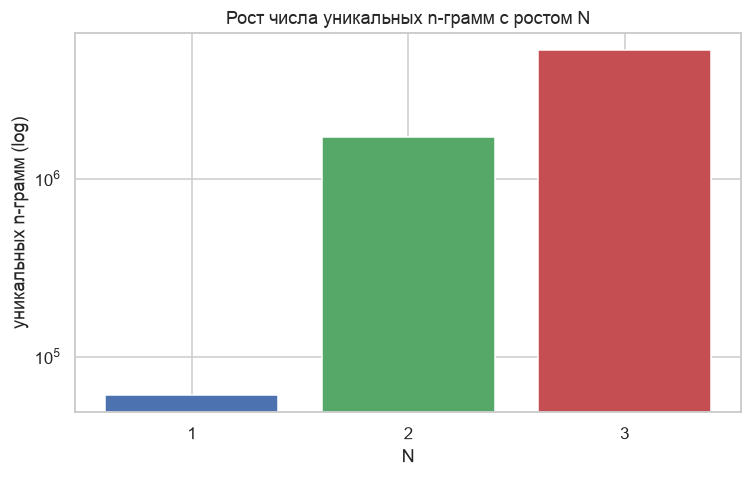

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(sparsity_df["N"].astype(str), sparsity_df["Уникальных n-грамм"], color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_yscale("log")
ax.set_xlabel("N"); ax.set_ylabel("уникальных n-грамм (log)")
ax.set_title("Рост числа уникальных n-грамм с ростом N")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_ngram_sparsity.png"))
plt.show()


Словарь всех типов токенов Train: 99239, из них 38365 (38.7%) hapax legomena, они заменены
на `[UNK]`, итоговый словарь модели: 60875 токенов. Доля `[UNK]` в самом Train после замены
0.37%, OOV rate на Test 0.69%: низкий процент ожидаем, так как лексика отзывов одного домена
пересекается между train и test. Число уникальных n-грамм растёт от 60875 (N=1) до 1.7 млн (N=2)
и 5.3 млн (N=3), доля n-грамм, встретившихся ровно 1 раз, растёт с 67.2% (биграммы) до 82.9%
(триграммы): статистика по более длинным контекстам скуднее, что напрямую скажется на перплексии
в Шаге 8.

### Шаг 8. Сглаживание вероятностей и перплексия

MLE-оценка вероятности n-граммы:

$$P_{MLE}(w_i \mid w_{i-n+1}^{i-1}) = \frac{\text{count}(w_{i-n+1}^{i})}{\text{count}(w_{i-n+1}^{i-1})}$$

Если n-грамма не встретилась в train, $P_{MLE}=0$, а по цепному правилу вероятность всего текста,
произведение вероятностей всех его n-грамм, тоже обращается в 0: перплексия становится
бесконечной.

Laplace (add-1): $P(w_i \mid ctx) = \dfrac{\text{count}(ctx, w_i) + 1}{\text{count}(ctx) + V}$

Lidstone (add-alpha): $P(w_i \mid ctx) = \dfrac{\text{count}(ctx, w_i) + \alpha}{\text{count}(ctx) + \alpha V}$
(Laplace, частный случай при alpha=1)

Перплексия считается в лог-пространстве:

$$PP(W) = 2^{-\frac{1}{N}\sum_{i=1}^{N} \log_2 P(w_i \mid ctx_i)}$$

Задание не требует подбора гиперпараметра, только сравнение перплексии со сглаживанием и без.
Поэтому значения alpha объявляются заранее, до расчёта перплексии на Test, без Validation и без
настройки по Test:

- Laplace, alpha=1 (классический базовый метод);
- Lidstone, alpha=0.5 (Expected Likelihood Estimation / Jeffreys-Perks);
- Lidstone, alpha=0.1 и alpha=0.01 (малые псевдочастоты, уместные при большом словаре).

Доля вероятностной массы, отводимая на все неучтённые в контексте события:
$\alpha V / (\text{count}(ctx) + \alpha V)$. Эта доля растёт с ростом alpha и падает с ростом
count(ctx): для частого контекста (много наблюдений) даже alpha=1 отводит на неучтённые события
заметную, но не подавляющую долю; для редкого контекста (мало наблюдений, типично для триграмм,
Шаг 7) даже небольшой alpha отводит почти всю массу. Точные доли для обоих случаев вычислены ниже
вместе с числовым примером.

In [36]:
def mle_prob(ngram, ngc, ctxc):
    context = ngram[:-1]
    c_ctx = ctxc.get(context, 0)
    if c_ctx == 0:
        return 0.0
    return ngc.get(ngram, 0) / c_ctx


def lidstone_prob(ngram, ngc, ctxc, v_size, alpha):
    context = ngram[:-1]
    num = ngc.get(ngram, 0) + alpha
    den = ctxc.get(context, 0) + alpha * v_size
    return num / den


def perplexity(token_lists, n, ngc, ctxc, v_size, alpha=None):
    total_log_prob = 0.0
    total_tokens = 0
    for tokens in token_lists:
        seq = pad_sequence(tokens, n)
        for i in range(n - 1, len(seq)):
            context = tuple(seq[i - n + 1:i])
            ngram = context + (seq[i],)
            p = mle_prob(ngram, ngc, ctxc) if alpha is None else lidstone_prob(ngram, ngc, ctxc, v_size, alpha)
            total_tokens += 1
            if p <= 0:
                return float("inf")
            total_log_prob += math.log2(p)
    return 2 ** (-(total_log_prob / total_tokens))


In [37]:
print("Перплексия без сглаживания (MLE) на Test:")
for n in (2, 3):
    pp = perplexity(test_unk, n, ngram_counts[n], context_counts[n], vocab_size, alpha=None)
    print(f"  N={n}: PP = {pp}")

n_demo = 3
seq0 = pad_sequence(test_unk[0], n_demo)
for i in range(n_demo - 1, len(seq0)):
    ctx = tuple(seq0[i - n_demo + 1:i])
    ng = ctx + (seq0[i],)
    if context_counts[n_demo].get(ctx, 0) == 0 or ngram_counts[n_demo].get(ng, 0) == 0:
        print(f"\nПример неувиденной триграммы: {ng}  "
              f"(count(context)={context_counts[n_demo].get(ctx, 0)}, count(ngram)={ngram_counts[n_demo].get(ng, 0)})"
              f"  -> P_MLE=0 -> перплексия текста = inf")
        break


Перплексия без сглаживания (MLE) на Test:
  N=2: PP = inf
  N=3: PP = inf

Пример неувиденной триграммы: ('this', 'after', '[UNK]')  (count(context)=27, count(ngram)=0)  -> P_MLE=0 -> перплексия текста = inf


In [38]:
ALPHA_SET = [1.0, 0.5, 0.1, 0.01]
ALPHA_LABELS = {1.0: "Laplace (alpha=1)", 0.5: "Lidstone (alpha=0.5, ELE)",
                0.1: "Lidstone (alpha=0.1)", 0.01: "Lidstone (alpha=0.01)"}

sensitivity_rows = []
for n in (2, 3):
    for alpha in ALPHA_SET:
        pp = perplexity(test_unk, n, ngram_counts[n], context_counts[n], vocab_size, alpha=alpha)
        sensitivity_rows.append({"Метод": ALPHA_LABELS[alpha], "alpha": alpha, "N": n, "PP_test": pp})

sensitivity_df = pd.DataFrame(sensitivity_rows)
pivot = sensitivity_df.pivot(index="Метод", columns="N", values="PP_test")
pivot = pivot.loc[[ALPHA_LABELS[a] for a in ALPHA_SET]]
pivot.columns = [f"N={n}" for n in pivot.columns]
pivot


,N=2,N=3
Метод,,
Laplace (alpha=1),1171.969480,11023.979684
"Lidstone (alpha=0.5, ELE)",857.220755,8008.724830
Lidstone (alpha=0.1),488.677878,3853.768545
Lidstone (alpha=0.01),325.454613,1723.232062


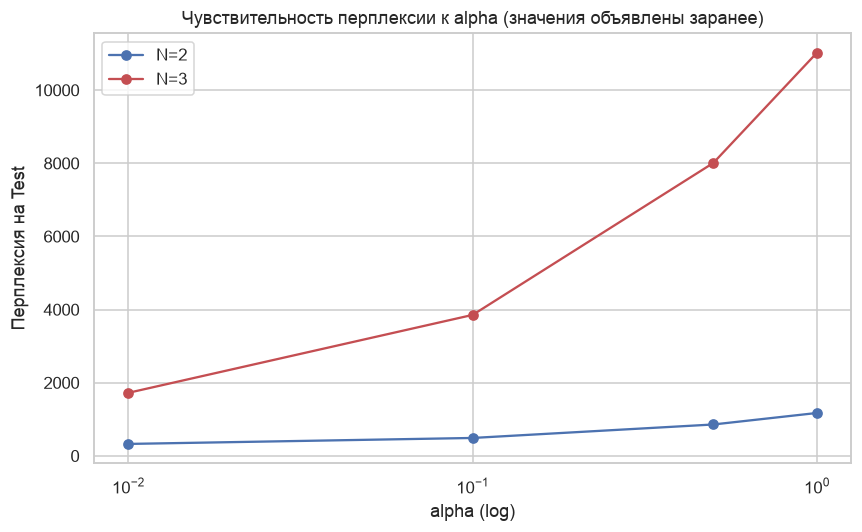

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
for n, color in [(2, "#4C72B0"), (3, "#C44E52")]:
    sub = sensitivity_df[sensitivity_df["N"] == n].sort_values("alpha")
    ax.plot(sub["alpha"], sub["PP_test"], marker="o", label=f"N={n}", color=color)
ax.set_xscale("log")
ax.set_xlabel("alpha (log)"); ax.set_ylabel("Перплексия на Test")
ax.set_title("Чувствительность перплексии к alpha (значения объявлены заранее)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_alpha_sensitivity.png"))
plt.show()


#### Кейс-стади: числовой пример

Два реальных биграммных контекста, самый частый и самый редкий среди буквенных слов train, для каждого
самое частое и заведомо неувиденное продолжение, плюс доля вероятностной массы, отводимая на все
неучтённые слова словаря целиком (не на одно слово).

In [40]:
def unseen_mass(c_ctx, alpha, v_size):
    return (alpha * v_size) / (c_ctx + alpha * v_size)


def show_case(ctx, label):
    seen_word = max(vocab_list, key=lambda w: ngram_counts[2].get(ctx + (w,), 0))
    unseen_word = next(w for w in vocab_list
                       if w.isalpha() and ngram_counts[2].get(ctx + (w,), 0) == 0)
    c_ctx = context_counts[2].get(ctx, 0)
    c_seen = ngram_counts[2].get(ctx + (seen_word,), 0)
    c_unseen = ngram_counts[2].get(ctx + (unseen_word,), 0)
    V = vocab_size
    print(f"--- {label}: context={ctx}, count(context)={c_ctx}, V={V} ---")
    print(f"seen='{seen_word}' count={c_seen}, unseen='{unseen_word}' count={c_unseen}")
    print(f"P_MLE(seen) = {c_seen}/{c_ctx} = {mle_prob(ctx+(seen_word,), ngram_counts[2], context_counts[2]):.6f}")
    print(f"P_MLE(unseen) = {c_unseen}/{c_ctx} = {mle_prob(ctx+(unseen_word,), ngram_counts[2], context_counts[2]):.6e}")
    for alpha in (1.0, 0.01):
        p_seen = lidstone_prob(ctx + (seen_word,), ngram_counts[2], context_counts[2], V, alpha)
        p_unseen = lidstone_prob(ctx + (unseen_word,), ngram_counts[2], context_counts[2], V, alpha)
        manual_seen = (c_seen + alpha) / (c_ctx + alpha * V)
        manual_unseen = (c_unseen + alpha) / (c_ctx + alpha * V)
        mass = unseen_mass(c_ctx, alpha, V)
        print(f"alpha={alpha}: P(seen) код={p_seen:.6f} вручную={manual_seen:.6f} | "
              f"P(unseen) код={p_unseen:.6e} вручную={manual_unseen:.6e} | "
              f"доля массы на все неучтённые слова = {mass:.1%}")
    print()


show_case(("this",), "частый контекст")

alpha_contexts = [c for c in context_counts[2] if c[0].isalpha()]
rare_ctx = min(alpha_contexts, key=lambda c: context_counts[2][c])
show_case(rare_ctx, "редкий контекст")


--- частый контекст: context=('this',), count(context)=119773, V=60875 ---
seen='movie' count=24949, unseen='aa' count=0
P_MLE(seen) = 24949/119773 = 0.208302
P_MLE(unseen) = 0/119773 = 0.000000e+00
alpha=1.0: P(seen) код=0.138114 вручную=0.138114 | P(unseen) код=5.535627e-06 вручную=5.535627e-06 | доля массы на все неучтённые слова = 33.7%
alpha=0.01: P(seen) код=0.207249 вручную=0.207249 | P(unseen) код=8.306907e-08 вручную=8.306907e-08 | доля массы на все неучтённые слова = 0.5%

--- редкий контекст: context=('pathogens',), count(context)=2, V=60875 ---
seen=',' count=1, unseen='a' count=0
P_MLE(seen) = 1/2 = 0.500000
P_MLE(unseen) = 0/2 = 0.000000e+00
alpha=1.0: P(seen) код=0.000033 вручную=0.000033 | P(unseen) код=1.642657e-05 вручную=1.642657e-05 | доля массы на все неучтённые слова = 100.0%
alpha=0.01: P(seen) код=0.001654 вручную=0.001654 | P(unseen) код=1.637331e-05 вручную=1.637331e-05 | доля массы на все неучтённые слова = 99.7%



#### Кейс-стади: сумма вероятностей по словарю равна 1

In [41]:
sample_contexts = [("this",), ("the",), ("movie",)]
for ctx in sample_contexts:
    for alpha in (1.0, 0.01):
        total = sum(lidstone_prob(ctx + (w,), ngram_counts[2], context_counts[2], vocab_size, alpha)
                    for w in vocab_list)
        print(f"context={ctx}, alpha={alpha}: сумма P(w|context) по словарю = {total:.10f}")


context=('this',), alpha=1.0: сумма P(w|context) по словарю = 1.0000000000
context=('this',), alpha=0.01: сумма P(w|context) по словарю = 1.0000000000
context=('the',), alpha=1.0: сумма P(w|context) по словарю = 1.0000000000
context=('the',), alpha=0.01: сумма P(w|context) по словарю = 1.0000000000
context=('movie',), alpha=1.0: сумма P(w|context) по словарю = 1.0000000000
context=('movie',), alpha=0.01: сумма P(w|context) по словарю = 1.0000000000


#### Кейс-стади: разложение перплексии Test на seen/unseen n-граммы

Оба кейс-стади ниже используют alpha=0.1, один из четырёх значений, объявленных в начале шага
(не 0.01: 0.1 ближе к середине объявленного диапазона и даёт умеренное, не крайнее сглаживание для
демонстрации структурных свойств модели).

In [42]:
ALPHA_CASE = 0.1
decomposition_rows = []
for n in (2, 3):
    seen_logs, unseen_logs = [], []
    for tokens in test_unk:
        seq = pad_sequence(tokens, n)
        for i in range(n - 1, len(seq)):
            context = tuple(seq[i - n + 1:i])
            ngram = context + (seq[i],)
            p = lidstone_prob(ngram, ngram_counts[n], context_counts[n], vocab_size, ALPHA_CASE)
            logp = math.log2(p)
            (seen_logs if ngram_counts[n].get(ngram, 0) > 0 else unseen_logs).append(logp)
    total = len(seen_logs) + len(unseen_logs)
    decomposition_rows.append({
        "N": n, "Доля seen": len(seen_logs) / total, "Доля unseen": len(unseen_logs) / total,
        "avg log2P seen": sum(seen_logs) / len(seen_logs) if seen_logs else float("nan"),
        "avg log2P unseen": sum(unseen_logs) / len(unseen_logs) if unseen_logs else float("nan"),
    })
decomposition_df = pd.DataFrame(decomposition_rows)
decomposition_df


,N,Доля seen,Доля unseen,avg log2P seen,avg log2P unseen
0,2,0.890656,0.109344,-7.975544,-16.729547
1,3,0.573949,0.426051,-8.899946,-15.969780


#### Кейс-стади: влияние порога `[UNK]` (min_count=1 vs 2)

In [43]:
vocab_words_mc1 = set(unigram_freq_train.keys())
vocab_words_mc1.add("[UNK]")
vocab_size_mc1 = len(vocab_words_mc1)

def map_unk_mc1(tokens):
    return [t if t in vocab_words_mc1 else "[UNK]" for t in tokens]

train_unk_mc1 = [map_unk_mc1(d) for d in train_tokens_list]
test_unk_mc1 = [map_unk_mc1(d) for d in test_tokens_list]

ngc_mc1, ctxc_mc1 = build_ngram_counts(train_unk_mc1, 2)

pp_mc1 = perplexity(test_unk_mc1, 2, ngc_mc1, ctxc_mc1, vocab_size_mc1, alpha=ALPHA_CASE)
pp_mc2 = perplexity(test_unk, 2, ngram_counts[2], context_counts[2], vocab_size, alpha=ALPHA_CASE)

unk_ablation_df = pd.DataFrame({
    "min_count": [1, 2],
    "Размер словаря": [vocab_size_mc1, vocab_size],
    f"Perplexity Test N=2 alpha={ALPHA_CASE}": [pp_mc1, pp_mc2],
})
unk_ablation_df


,min_count,Размер словаря,Perplexity Test N=2 alpha=0.1
0,1,99240,644.532868
1,2,60875,488.677878


**Вывод по шагу 8.** Без сглаживания перплексия на Test бесконечна для N=2 и N=3: пример
выше, триграмма `('this', 'after', '[UNK]')`, контекст встречался 27 раз, но именно с этим
продолжением ни разу, дающая $P_{MLE}=0$. В таблице чувствительности перплексия растёт
монотонно с ростом alpha, от 325 (N=2) / 1723 (N=3) при alpha=0.01 до 1172 / 11024 при alpha=1,
как и предсказывает формула: доля массы под неучтённые события растёт вместе с alpha*V. Для
любого объявленного alpha N=3 хуже N=2. Минимум среди четырёх значений приходится на самый
маленький объявленный alpha=0.01, это граница проверенного диапазона: сгладится ли перплексия
дальше или начнёт расти при alpha меньше 0.01, не проверялось, alpha меньше объявленного набора
не тестируется, чтобы не превратить сравнение в скрытый подбор.

Числовой пример подтверждает код формулами напрямую: при alpha=1 вероятность неувиденного слова
после `this` падает до 0.000006 против 0.138 у самого частого продолжения, при alpha=0.01 разница
ещё резче. Сумма вероятностей по словарю равна 1 с точностью до 10 знаков для всех проверенных
контекстов и alpha, реализация корректна.

Разложение на seen/unseen объясняет разницу перплексий N=2 и N=3 числами: для N=2 89.1% токенов
Test встречаются с уже виденным контекстом, для N=3 только 57.4% (unseen 10.9% и 42.6%
соответственно). log2P у unseen-токенов ниже (хуже) в обоих случаях, решающий фактор это доля:
у N=3 в 3.9 раза больше токенов Test приходится на unseen-случаи, чем у N=2.

Абляция `[UNK]`: при одинаковом alpha=0.1 перплексия с min_count=1 (словарь 99240) равна 644.5,
с min_count=2 (словарь 60875) равна 488.7. Эти два числа напрямую не сравнимы как оценка "какая
модель лучше": у моделей разный словарь V, а при min_count=2 часть редких слов Test, которые при
min_count=1 остаются штучными и трудно предсказуемыми токенами, объединяются в категорию `[UNK]`
с гораздо большей статистикой, что механически снижает перплексию независимо от реального качества
предсказаний. Разница чисел показывает, что перплексия чувствительна к определению словаря, а не
доказывает превосходство min_count=2. Порог min_count=2 обоснован независимо, Шагом 6: заметная
часть hapax-слов train, опечатки.

### Шаг 9. Генерация текста на основе марковской цепи

N-граммная модель задаёт марковскую цепь порядка N-1: следующее слово выбирается по распределению,
которое зависит от предыдущих N-1 слов. Генерация начинается с токена `<s>` и заканчивается на
`</s>` или при достижении максимальной длины (50 токенов), температура сэмплирования 0.8.

Для генерации не используется сглаживание Lidstone. Сглаживание нужно в Шаге 8, чтобы перплексия на
Test была конечной, но при сэмплировании оно добавляет в распределение "хвост" слов, ни разу не
встречавшихся после данного контекста. Его масса равна $\alpha V / (\text{count}(ctx) + \alpha V)$.
Если контекст встретился мало раз, эта масса близка к 100% (см. кейс "редкий контекст" в Шаге 8), и
слово из такого хвоста будет выбрано почти наверняка. Для триграмм такие контексты типичны:
медианное число наблюдений триграммного контекста в train равно 1, а доля контекстов с одним
наблюдением или меньше составляет 67.2% (расчёт ниже).

Поэтому слово выбирается только из тех, что реально встречались после текущего контекста в train,
с вероятностью, пропорциональной частоте (это MLE-распределение). Если контекст не встречался ни
разу, применяется backoff: для N=3 сначала к биграммной модели по последнему слову, затем к
униграммной. Для N=2 backoff нужен только на униграмму. Backoff используется только при
генерации и не участвует в расчёте перплексии в Шаге 8. Основная модель генерации - N=2, для N=3
приведено сравнение.

In [44]:
ctx3_counts = list(context_counts[3].values())
median_ctx3 = sorted(ctx3_counts)[len(ctx3_counts) // 2]
zero_share_est = sum(1 for c in ctx3_counts if c <= 1) / len(ctx3_counts)
print(f"Число различных триграммных контекстов, встретившихся хотя бы раз: {len(ctx3_counts):,}")
print(f"Медианное число наблюдений среди них: {median_ctx3}")
print(f"Доля контекстов с <=1 наблюдением: {zero_share_est:.1%}")


Число различных триграммных контекстов, встретившихся хотя бы раз: 1,703,846
Медианное число наблюдений среди них: 1
Доля контекстов с <=1 наблюдением: 67.2%


In [45]:
def build_next_word_index(ngc):
    index = defaultdict(list)
    for ngram, c in ngc.items():
        index[ngram[:-1]].append((ngram[-1], c))
    return index


def sample_known(context, next_word_index, temperature, rng):
    known = next_word_index.get(context, [])
    if not known:
        return None
    words = [w for w, _ in known]
    weights = [c ** (1 / temperature) for _, c in known]
    total = sum(weights)
    r = rng.random() * total
    acc = 0.0
    for w, wt in zip(words, weights):
        acc += wt
        if r <= acc:
            return w
    return words[-1]


def generate_bigram(next_idx2, next_idx1, max_len=50, temperature=1.0, rng=None):
    rng = rng or random.Random()
    context = ("<s>",)
    output = ["<s>"]
    for _ in range(max_len):
        w = sample_known(context, next_idx2, temperature, rng)
        if w is None:
            w = sample_known((), next_idx1, temperature, rng)
        output.append(w)
        if w == "</s>":
            break
        context = (w,)
    return output


def generate_trigram_backoff(next_idx3, next_idx2, next_idx1, max_len=50, temperature=1.0, rng=None):
    rng = rng or random.Random()
    context = ("<s>", "<s>")
    output = ["<s>"]
    for _ in range(max_len):
        w = sample_known(context, next_idx3, temperature, rng)
        if w is None:
            w = sample_known(context[-1:], next_idx2, temperature, rng)
        if w is None:
            w = sample_known((), next_idx1, temperature, rng)
        output.append(w)
        if w == "</s>":
            break
        context = (context[-1], w)
    return output


In [46]:
next_idx1 = build_next_word_index(ngram_counts[1])
next_idx2 = build_next_word_index(ngram_counts[2])
next_idx3 = build_next_word_index(ngram_counts[3])

generated_texts = {}

rng2 = random.Random(SEED)
generated_texts[2] = [generate_bigram(next_idx2, next_idx1, max_len=50, temperature=0.8, rng=rng2)
                      for _ in range(5)]

rng3 = random.Random(SEED)
generated_texts[3] = [generate_trigram_backoff(next_idx3, next_idx2, next_idx1, max_len=50, temperature=0.8, rng=rng3)
                      for _ in range(5)]

for n in (2, 3):
    print(f"=== N={n} ===")
    for t in generated_texts[n]:
        print(" ".join(t))
        print()


=== N=2 ===
<s> this movie was a show is because the movie is a new to the process of the worst comedy . but , the film hits the way , for me wrong , but quite as well developed a writer and though the best supporting players . i really comes across

<s> the [num] s more in one of a bunch of details . this is far , this movie . the [num] called storm in their boat chase in the script . the worst pictures are so tangled up in the film was never come up and curiously , carl .

<s> i would get the scene in the movie . upon [UNK] is an actor who's absolutely no attempt to the the same subject matter how long time round that could have never imagined applause to a very realistic movie is so . the absurd . </s>

<s> this one of the festering heap of the film . the worst movie was the very much this show . if there is a desperate situation . but she is the movie . as if there he is not a soap opera house of the first , nor was hoping

<s> this movie preaches that kinnear in your time , is not

**Оценка связности и адекватности.** Все 10 текстов локально правдоподобны: на уровне коротких
словосочетаний грамматика в основном верна (`he didn't even pay attention to detail`, `the supporting
cast looked like a reindeer in the opening sequence`, N=3), но на длине целой фразы связность
пропадает: (`the worst pictures are so tangled up in the film was never come up and curiously , carl .`,
N=2; `no attempt to the the same subject matter how long time round that could have never imagined
applause to a very realistic movie is so .`, N=2). N=3 чаще держит грамматику на отрезке 5-6 слов, но
отчасти за счёт копирования фрагментов train (см. проверку ниже). Тема подменяется на середине
фразы, единой сюжетной линии и логического завершения нет ни у одной модели: память в 1-2
предыдущих слова не позволяет удерживать тему дальше нескольких слов.

#### Проверка дословного копирования из train

Строка-индекс train строится один раз (все токены train через пробел), для каждого сгенерированного
текста ищется самый длинный непрерывный фрагмент, который целиком совпадает с фрагментом train,
и сам этот фрагмент выводится, а не только его длина.

In [47]:
train_corpus_str = " " + " ".join(" ".join(doc) for doc in train_unk) + " "
print(f"Индекс train построен один раз, {len(train_corpus_str):,} символов")

def longest_copied_span(tokens, corpus_str):
    best, best_span = 0, []
    n = len(tokens)
    for start in range(n):
        length = 1
        while start + length <= n:
            candidate = tokens[start:start + length]
            span = " " + " ".join(candidate) + " "
            if span in corpus_str:
                if length > best:
                    best, best_span = length, candidate
                length += 1
            else:
                break
    return best, best_span


t0 = time.time()
copy_rows = []
for n, texts in generated_texts.items():
    for idx, t in enumerate(texts, start=1):
        span, span_tokens = longest_copied_span(t, train_corpus_str)
        copy_rows.append({"N": n, "text_id": idx, "длина текста": len(t),
                           "макс. совпадение, токенов": span, "пример фрагмента": " ".join(span_tokens)})
copy_df = pd.DataFrame(copy_rows)
print(f"Проверка заняла {time.time()-t0:.2f}с")
copy_df


Индекс train построен один раз, 52,136,139 символов


Проверка заняла 12.13с


,N,text_id,длина текста,"макс. совпадение, токенов",пример фрагмента
0,2,1,51,5,<s> this movie was a
1,2,2,51,5,", this movie . the"
2,2,3,47,5,the scene in the movie
3,2,4,51,5,<s> this one of the
4,2,5,51,5,the whole movie . it
5,3,1,51,6,this film is what it is
6,3,2,51,6,seems to be a bit of
7,3,3,51,6,a church hierarchy including priests and
8,3,4,51,5,", or if it was"
9,3,5,51,8,", for example we've been clumsily led to"


Максимальное дословное совпадение с train, по всем 10 текстам, от 5 до 8 токенов (таблица
выше показывает сам фрагмент для каждого текста, не только длину). Это короткие обороты вроде
`<s> this movie was a` или `seems to be a bit of`, ожидаемые при более чем 10 млн токенов train:
такие короткие последовательности многократно встречаются в корпусе независимо от конкретного
сгенерированного текста. Совпадений длиной в целое предложение не найдено ни у одного текста.

### Шаг 10. Заключение

На 49582 рецензиях после удаления 418 дублей выполнено разбиение Train/Test 80/20 (39665/9917) со
стратификацией по `sentiment`, без Validation. Конвейер очистки на `re` устраняет HTML-теги, URL,
e-mail (0 остатков после очистки), заменяет числа на `[NUM]`, сохраняет сокращения и отрицания,
добавляет `<s>`/`</s>` к каждому документу. Стемминг и лемматизация сравнены по словарю и времени:
лемматизация лингвистически точнее, но на порядки медленнее из-за POS-тэггинга. Расстояние
Левенштейна реализовано вручную с оптимизацией по памяти, индекс удалений находит кандидатов в
опечатки без перебора всех пар словаря.

N-граммная модель (N=2, N=3) построена на словаре с `[UNK]` для hapax-слов train, OOV на Test
0.69%. Без сглаживания перплексия бесконечна, с Lidstone конечна и растёт монотонно с alpha, как
предсказывает формула доли неучтённой массы. N=3 стабильно хуже N=2: доля токенов Test с виденным
контекстом падает с 89.1% (N=2) до 57.4% (N=3). Порог `min_count=2` для `[UNK]` обоснован Шагом 6
(hapax-слова train часто опечатки), а не сравнением перплексии между разными словарями: такое
сравнение само по себе методологически некорректно (Шаг 8, абляция UNK).

Генерация текста сэмплирует только наблюдённые продолжения (MLE, без сглаживания), с backoff к
биграмме и униграмме при нулевой статистике контекста: медианное число наблюдений триграммного
контекста в train равно 1, и любое сглаживание при таком малом count(ctx) почти целиком отдаёт
вероятностную массу случайным словам. Оба N=2 и N=3 дают связный текст на уровне словосочетаний и
простых клауз, без связности на уровне целого текста. Дословные совпадения с train по всем 10
текстам не превышают 8 токенов, коротких оборотов, ожидаемых в корпусе с более чем 10 млн токенов.

**Ограничения.** N-граммная модель без интерполяции/backoff в оценке перплексии резко теряет
качество при разреженном контексте, это структурное свойство подхода. Память модели ограничена
N-1 словами, семантика целого текста недостижима при N<=3. Инструментарий (NLTK) ориентирован на
английский язык.